# Exercício 03

**Instruções gerais:** Sua submissão <u>deve</u> conter:
1. Um "ipynb" com seu código e as soluções dos problemas
2. Uma versão pdf do ipynb

Caso você opte por resolver as questões de "papel e caneta" em um editor de $\LaTeX$ externo, o inclua no final da versão pdf do 'ipynb'--- submetendo um <u>único pdf</u>.

## Redução de dimensionalidade

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
import seaborn as sns
import io
import base64

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader
import tqdm

import time

**1.** Considere o conjunto de dados disponível em penguins.csv, organizado em 5
colunas, sendo 4 colunas de atributos e a última a classe do padrão. Os dados
referem-se a medições anatômicas de pinguins da Antártida, classificados nas
espécies Adelie, Chinstrap e Gentoo. Maiores detalhes sobre os dados podem
ser achados em https://allisonhorst.github.io/palmerpenguins/.

**a)** Apresente a projeção em 2 dimensões dos padrões acima obtida pelo método PCA (análise dos componentes principais).

**b)** Ainda considerando o item anterior, calcule e mostre a variância explicada obtida quando a dimensão projetada é modificada (1,2,3 ou 4).

Normalize os dados antes de executar PCA. Implemente sua própria versão de PCA, mas verifique a corretude comparando contra alguma implementação popular (e.g., da biblioteca scikitlearn).

In [3]:
# Importando o dataset:
data = torch.from_numpy(pd.read_csv("./penguins.csv", header=None).to_numpy())

Primeiro, criaremos uma função para aplicar o método PCA:

In [4]:
def pca_method(data, n_dim = 2):

    covariav = data.iloc[:, 0:4]
    target = data.iloc[:, 4]

    if n_dim > covariav.shape[1]:

        raise Exception('n_dim não pode ser maior que o número de covariaveis')

    else:
        # normalizamos os dados
        covariav = (covariav - covariav.mean()) / covariav.std()

        # construimos a matriz de covariancia
        cov = covariav.cov()

        # pegamos autovalores e autovetores
        eigvals, eigvecs = np.linalg.eig(cov)

        # fazendo o sort
        idx = eigvals.argsort()[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:,idx]

        # pegamos 2 componentes do PCA, ou seja, os dois autovetores com os maiores autovalores
        pca_1 = eigvecs[:, 0: n_dim]

        # desse modo, reduzimos os dados para 2 dimensões
        covariav = np.dot(covariav, pca_1)

        penguins_reduced = np.concatenate((covariav, np.array(target).reshape(-1, 1)), axis = 1)

        colnames = []
        for i in range(covariav.shape[1]):
            colnames.append('Componente Principal ' + str(i + 1))
        colnames.append('Especies')

        # dataframe
        penguins_reduced = pd.DataFrame(penguins_reduced, columns = colnames)
        penguins_reduced['Especies'] = penguins_reduced['Especies'].astype('category')

        return penguins_reduced, eigvals

podemos aplicar o PCA com n_dim=2, com o intuito de fazer um plot dos dados projetados em 2 dimensões:

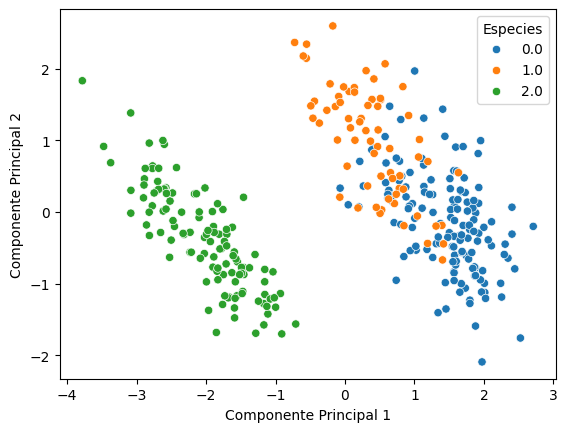

In [9]:
penguins_reduced, eigvals = pca_method(pd.DataFrame(data.numpy()), n_dim = 2)

sns.scatterplot(penguins_reduced, x='Componente Principal 1', y='Componente Principal 2', hue='Especies')
plt.show()

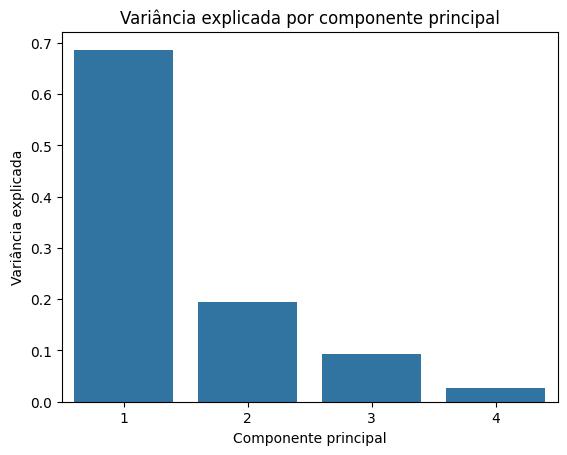

In [10]:
# calculando a variancia explicada
explained_variance_ratio = eigvals / eigvals.sum()
explained_variance_ratio

# plot
sns.barplot(x=[1,2,3,4], y=explained_variance_ratio)
plt.xlabel('Componente principal')
plt.ylabel('Variância explicada')
plt.title('Variância explicada por componente principal')
plt.show()

Ao calcularmos a variância explicada, percebemos que a primeira componente responde pela maior parte da variação nos dados. A segunda componente explica a próxima maior parcela, e essa tendência se repete para as componentes subsequentes.

Agora, para validar nossos resultados, vamos compará-los com uma implementação comum, como a do scikit-learn, utilizando o mesmo conjunto de dados

**2.** Implemente um autoencoder determinísitco para o banco de dados MNIST, que já usamos em exercícios anteriores. Você pode escolher utilizar tanto CNN como MLP no encoder/decoder. No entanto, o encoder deve mapear as imagens no $\mathbb{R}^2$, para podermos visualizar as representações latentes no plano. Use o conjunto de validação para fazer early stopping. Você também pode monitorar o erro na validação para anelar a taxa de aprendizado (usando um scheduler). Finalmente, mostre a projeção das imagens de teste no espaço latente e comente qualitativamente os embeddings obtidos.

In [14]:
train_val_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor(),
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.46MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 161kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.02MB/s]


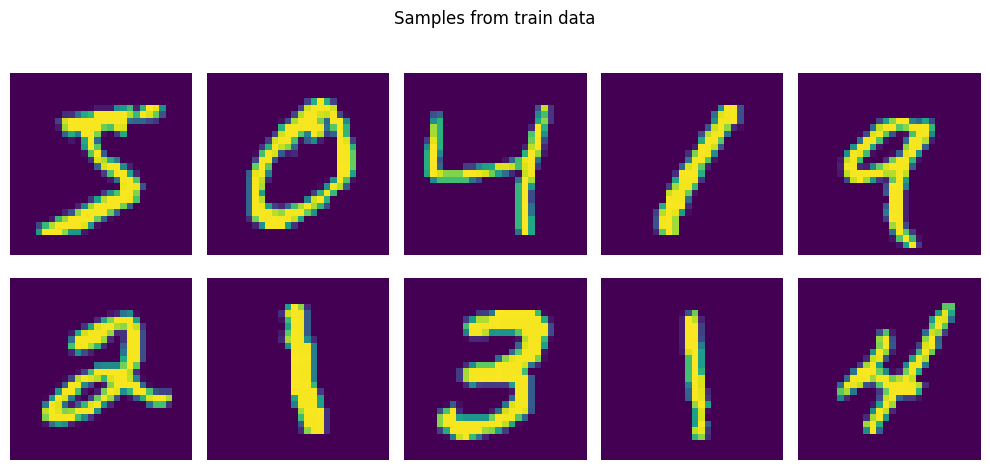

In [15]:
fig, ax = plt.subplots(2,5, figsize=(10,5))

for i in range(10):
    ax[i//5,i%5].imshow(train_val_dataset.data[i])
    ax[i//5,i%5].axis('off')

fig.suptitle("Samples from train data")
fig.tight_layout()

In [16]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(2, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 28*28)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return torch.sigmoid(self.fc3(x))

In [23]:
loss = nn.MSELoss()
lr = 0.001
encoder = Encoder()
decoder = Decoder()

# optimizer
optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=lr)

# Split train_val_dataset into training and validation sets
train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


# treinando o modelo
epochs = 10
for epoch in range(epochs):
    for batch in train_loader:
        optimizer.zero_grad()
        x, _ = batch
        encoded = encoder(x)
        decoded = decoder(encoded)
        l = loss(decoded, x.view(-1, 28*28))
        l.backward()
        optimizer.step()
    print(f'Epoch: {epoch+1}, Loss: {l.item()}')

Epoch: 1, Loss: 0.049843013286590576
Epoch: 2, Loss: 0.04742679372429848
Epoch: 3, Loss: 0.048502884805202484
Epoch: 4, Loss: 0.046426787972450256
Epoch: 5, Loss: 0.042694997042417526
Epoch: 6, Loss: 0.04766951873898506
Epoch: 7, Loss: 0.0402391217648983
Epoch: 8, Loss: 0.04142992943525314
Epoch: 9, Loss: 0.04036137834191322
Epoch: 10, Loss: 0.03678493574261665


Verificando nosso modelo:


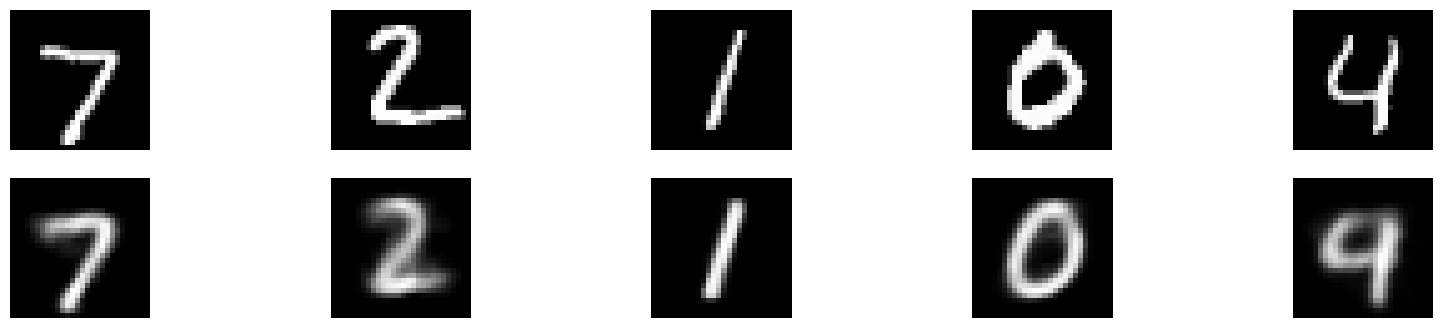

In [21]:
# Create DataLoader for test data
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

for batch in test_loader:
    x, _ = batch
    encoded = encoder(x)
    decoded = decoder(encoded)
    break

fig, ax = plt.subplots(2, 5, figsize=(20, 4))
for i in range(5):
    ax[0, i].imshow(x[i].view(28, 28), cmap='gray')
    ax[1, i].imshow(decoded[i].detach().view(28, 28), cmap='gray')
    ax[0, i].axis('off')
    ax[1, i].axis('off')

Esses valores realmente correspondem às dimensões dos inputs e fazem sentido como reduções progressivas. Agora, vamos visualizar a projeção das imagens de validação no espaço latente:

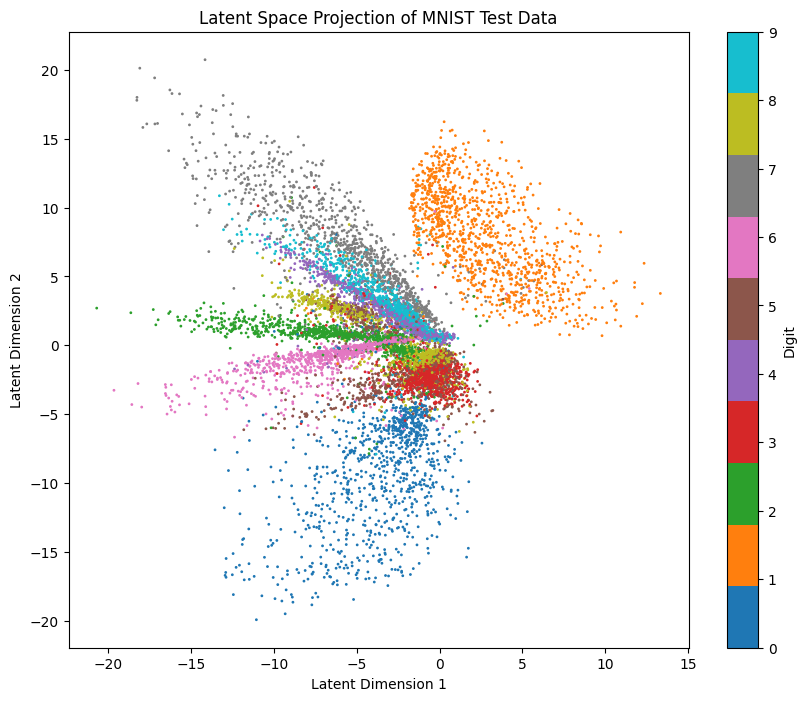

In [24]:
# espaco latente para o test_data
def plot_latent(data_loader):
    all_encoded = []
    all_labels = []
    for x, y in data_loader:
        encoded = encoder(x)
        all_encoded.append(encoded.detach())
        all_labels.append(y)

    all_encoded = torch.cat(all_encoded, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(all_encoded[:, 0], all_encoded[:, 1], c=all_labels, cmap='tab10', s=1)
    plt.colorbar(scatter, label='Digit')
    plt.title('Latent Space Projection of MNIST Test Data')
    plt.xlabel('Latent Dimension 1')
    plt.ylabel('Latent Dimension 2')
    plt.show()


plot_latent(test_loader)

## K-means e Mixture models

## Exercícios práticos

In [25]:
mnist_trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True,
                                            transform=torchvision.transforms.ToTensor())
fashion_mnist_trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True,
                                                           transform=torchvision.transforms.ToTensor())

mnist_testset = torchvision.datasets.MNIST(root='./data', train=False, download=True,
                                            transform=torchvision.transforms.ToTensor())

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.53MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 133kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.48MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.8MB/s]


In [26]:
def display_nine_images(dataset):
    for i, (image, label) in enumerate(dataset):
        plt.subplot(3, 3, i + 1)
        plt.imshow(image.permute(1, 2, 0), cmap='gray')
        plt.axis('off')
        plt.title(f'Label: {label}')
        if i >= 8: break
    plt.suptitle(dataset.__class__.__name__)
    plt.tight_layout()

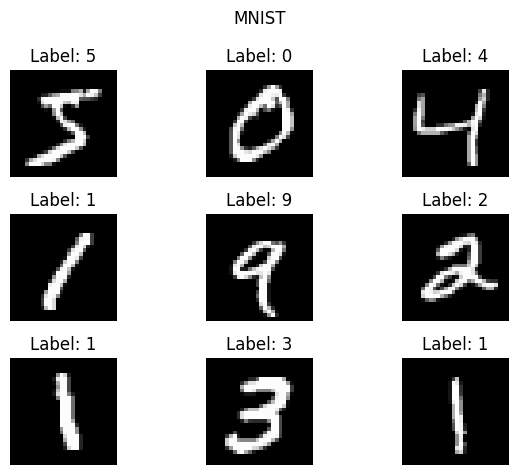

In [27]:
display_nine_images(mnist_trainset)

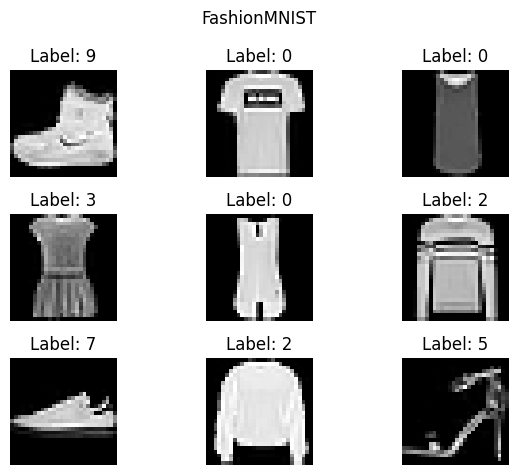

In [28]:
display_nine_images(fashion_mnist_trainset)

**1.** Implemente o algoritmo de $K$-means e aplique-o ao MNIST usando $K=10$ (o número de dígitos no banco de dados) --- inicializando os centroides aleatoriamente ou usando a estratégia do k-means++. Considere também inicializar os centróides como as médias das imagens de cada classe (é possível já que MNIST possui labels). Em geral, imagens similares são agrupadas junto? Plote exemplos de amostras em cada cluster.

In [29]:
# transformando as imagens de entrada em vetores de uma dimensão:
train_mnist = mnist_trainset.data.numpy()
train_mnist = train_mnist.reshape(train_mnist.shape[0], -1)
train_mnist

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [40]:
import random
# número de clusters
k = 10

# inicialização aleatória dos centroides
m, n  = np.shape(train_mnist)
centroids = np.empty((k, n))
for i in range(k):
    centroids[i] = train_mnist[random.randint(0,m)]

# escolhemos o centroide mais próximo para cada ponto (Otimizado)
def get_closest_centroid(data, centroids):
    # Calculate squared distances using broadcasting
    # (data - centroids)^2 = data^2 - 2*data*centroids + centroids^2
    # We only need the squared distances to find the minimum, avoiding sqrt
    data_sq = np.sum(data**2, axis=1, keepdims=True)
    centroids_sq = np.sum(centroids**2, axis=1, keepdims=True)
    dot_product = np.dot(data, centroids.T)
    squared_dists = data_sq - 2 * dot_product + centroids_sq.T
    return np.argmin(squared_dists, axis=1)


# atualizamos os centroides
def update_centroids(data, closest_centroids):
    new_centroids = np.empty((k, n))
    for i in range(k):
        # Handle empty clusters
        if np.sum(closest_centroids == i) > 0:
            new_centroids[i] = np.mean(data[closest_centroids == i], axis=0)
        else:
             # If a cluster is empty, reinitialize its centroid randomly
             new_centroids[i] = train_mnist[random.randint(0,m)]

    return new_centroids

# Definimos a função de k-means
def k_means(data, centroids):
    closest_centroids = get_closest_centroid(data, centroids)
    new_centroids = update_centroids(data, closest_centroids)
    # Added a maximum iteration limit to prevent infinite loops
    max_iterations = 100
    for _ in range(max_iterations):
        if np.array_equal(centroids, new_centroids): # tenemos como criterio de parada la no-modificacion de los centroides
            break
        centroids = new_centroids
        closest_centroids = get_closest_centroid(data, centroids)
        new_centroids = update_centroids(data, closest_centroids)
    return centroids, closest_centroids

# Note: The k-means++ initialization is in the next cell (PryKnmUJaVdC)
# This cell only defines the functions.

In [32]:
# Precisamos também definir funções para reconhecer qual a label mais comum em cada centroide
def get_most_common_label(data, closest_centroids):
    labels = {}
    for i in range(k):
        labels[i] = np.argmax(np.bincount(data[closest_centroids == i]))
    return labels

labels = get_most_common_label(mnist_trainset.targets, closest_centroids)

def map_labels(closest_centroids, labels):
    mapped_labels = np.empty_like(closest_centroids)
    for i in range(k):
        mapped_labels[closest_centroids == i] = labels[i]
    return mapped_labels

mapped_labels = map_labels(closest_centroids, labels)

Agora, podemos criar uma matriz de confusão para ver como os clusters se relacionam com as labels, utilizando as funções anteriores para mapear os clusters de acordo com as labels:

Text(0.5, 1.0, 'Matriz de Confusão do Conjunto MNIST - Inicialização Aleatória')

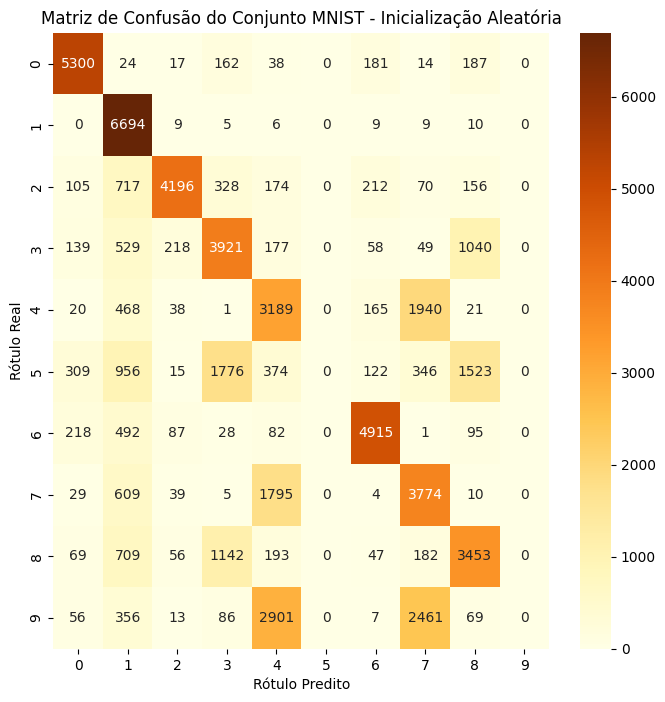

In [34]:
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(mnist_trainset.targets, mapped_labels)
fig = plt.figure(figsize=(8,8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlOrBr')
plt.xlabel('Rótulo Predito')
plt.ylabel('Rótulo Real')
plt.title('Matriz de Confusão do Conjunto MNIST - Inicialização Aleatória')

As imagens de cada cluster:


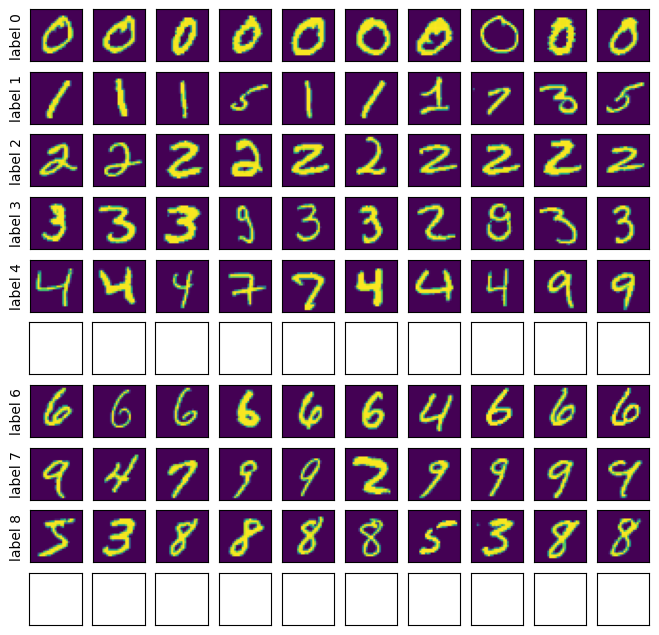

In [42]:
def plot_sample(data, mapped_labels):
    fig, ax = plt.subplots(k, 10, figsize=(8, 8))
    for i in range(k):
        for j in range(10):
            if len(data.data[mapped_labels == i]) >= 10:
                ax[i, j].imshow(data.data[mapped_labels == i][j])
                if j == 0:
                    ax[i, j].set_ylabel(f'label {mapped_labels[mapped_labels == i][j]}')
    plt.setp(ax, xticks=[], yticks=[])
    plt.show()

plot_sample(mnist_trainset, mapped_labels)

Apesar de algumas exceções, os clusters representam razoavelmente bem os dígitos. Um aspecto interessante é que não há um cluster específico associado ao dígito 5, que acabou sendo distribuído entre outros clusters — como pode ser observado, por exemplo, nos clusters correspondentes aos dígitos 1 e 8.

Agora, repetiremos o processo, mas desta vez inicializando os centróides com a estratégia do k-means++.

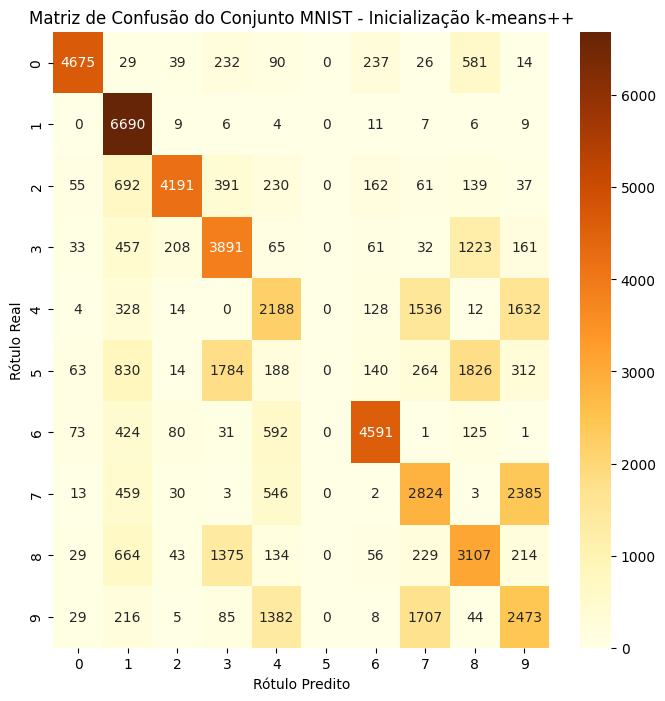

In [43]:
import random # Import random again for this cell

centroids = np.empty((k, n))
# Select the first centroid randomly
centroids[0] = train_mnist[random.randint(0,m)]

# Select the remaining centroids using k-means++ logic
for i in range(1, k):
    # Calculate squared distances to the already selected centroids
    data_sq = np.sum(train_mnist**2, axis=1, keepdims=True)
    centroids_sq = np.sum(centroids[:i]**2, axis=1, keepdims=True)
    dot_product = np.dot(train_mnist, centroids[:i].T)
    squared_dists = data_sq - 2 * dot_product + centroids_sq.T

    # Find the minimum squared distance for each data point
    min_squared_dist = np.min(squared_dists, axis=1)

    # Calculate probabilities proportional to the minimum squared distance
    probs = min_squared_dist / np.sum(min_squared_dist)

    # Select the next centroid based on the probabilities
    centroids[i] = train_mnist[np.random.choice(train_mnist.shape[0], p=probs)]

# Run k-means with k-means++ initialized centroids
centroids, closest_centroids = k_means(train_mnist, centroids)

# Get the most common label for each cluster
labels = get_most_common_label(mnist_trainset.targets, closest_centroids)

# Map the cluster assignments to the most common labels
mapped_labels = map_labels(closest_centroids, labels)

# Calculate and display the confusion matrix
conf_matrix = confusion_matrix(mnist_trainset.targets, mapped_labels)
fig = plt.figure(figsize=(8,8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlOrBr')
plt.xlabel('Rótulo Predito')
plt.ylabel('Rótulo Real')
plt.title('Matriz de Confusão do Conjunto MNIST - Inicialização k-means++')
plt.show() # Added plt.show() to display the plot

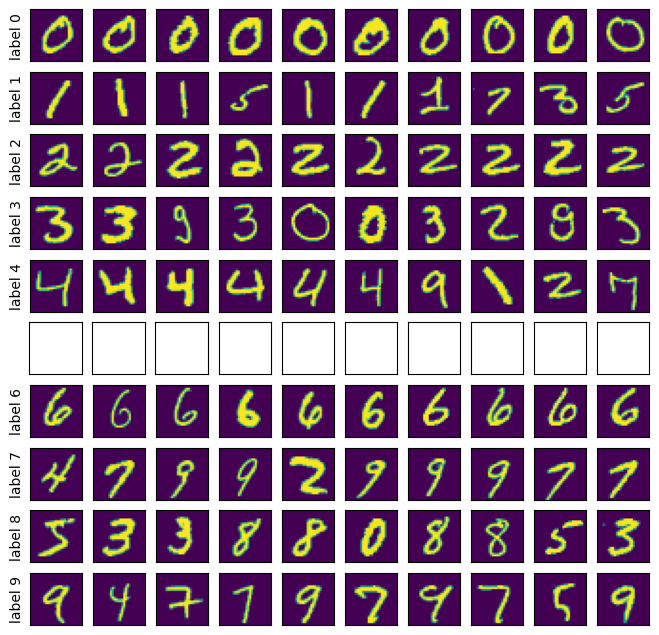

In [44]:
plot_sample(mnist_trainset, mapped_labels)

Em comparação com o k-means++, os resultados foram bastante semelhantes, novamente indicando a ausência de agrupamentos distintos para os dígitos 5 e 9. No entanto, a matriz de confusão revela um bom desempenho para os demais números, e as amostras visualizadas oferecem uma representação fiel dos dígitos. De modo geral, os agrupamentos refletem com precisão a similaridade entre as imagens, e os erros identificados parecem razoáveis. Por exemplo, ao observar as amostras, é compreensível que o dígito 9 seja frequentemente confundido com o 7 devido à sua forma semelhante.

**2.** Gaussian Mixture Models (GMMs) são estimadores de densidade poderosos. Podemos utilizá-los, por exemplo, para detectar amostras "fora da distribuição de treino" (out-of-distribution, OOD) em tempo de teste, evitando possíveis previsões catastróficias. Com isso em mente:
- (a) treine um MLP para classificar o MNIST;
- (b) com o MLP treinado, use um GMM para modelar as ativações da penúltima camada desse MLP (usando as ativações dos dados de treino);
- (c) avalie a capacidade dessa GMM em diferenciar amostras de teste do MNIST e do FashionMNIST (espera-se que amostras OOD --- do FashionMNIST--- estejam nas caudas);
- (d) teste essa estratégia com números diferentes de componente das misturas e escolha a que provê a melhor separação.

Para simplificar sua vida, use a implementação de GMM do scikit-learn.

In [45]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = DataLoader(mnist_trainset, batch_size=64, shuffle=True)
test_loader = DataLoader(mnist_testset, batch_size=64, shuffle=True)

In [46]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.linear2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.linear3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear1(x)
        x = self.relu1(x)
        x = self.linear2(x)
        activation = self.relu2(x)
        x = self.linear3(activation)
        return x, activation

# defimos o modelo
model = NeuralNetwork(784, 128, 10).to(device)

# definimos a loss function
lossFunc = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

Treinando o modelo. Usaremos 100 épocas:

In [47]:
for epoch in range(100):
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        # forward pass
        outputs, activations_train = model(images)
        loss = lossFunc(outputs, labels)
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Época: {epoch + 1}, Loss: {loss.item():.4f}')

Época: 1, Loss: 2.3028
Época: 2, Loss: 2.2422
Época: 3, Loss: 2.1651
Época: 4, Loss: 1.9971
Época: 5, Loss: 1.8688
Época: 6, Loss: 1.6518
Época: 7, Loss: 1.2589
Época: 8, Loss: 1.1927
Época: 9, Loss: 0.7193
Época: 10, Loss: 0.9053
Época: 11, Loss: 0.7583
Época: 12, Loss: 0.5527
Época: 13, Loss: 0.9048
Época: 14, Loss: 0.3258
Época: 15, Loss: 0.5429
Época: 16, Loss: 0.4437
Época: 17, Loss: 0.5141
Época: 18, Loss: 0.3841
Época: 19, Loss: 0.4097
Época: 20, Loss: 0.5447
Época: 21, Loss: 0.4874
Época: 22, Loss: 0.2905
Época: 23, Loss: 0.3617
Época: 24, Loss: 0.4395
Época: 25, Loss: 0.5381
Época: 26, Loss: 0.4404
Época: 27, Loss: 0.2191
Época: 28, Loss: 0.2857
Época: 29, Loss: 0.4479
Época: 30, Loss: 0.4995
Época: 31, Loss: 0.3178
Época: 32, Loss: 0.3758
Época: 33, Loss: 0.1383
Época: 34, Loss: 0.1919
Época: 35, Loss: 0.2033
Época: 36, Loss: 0.2027
Época: 37, Loss: 0.5634
Época: 38, Loss: 0.1871
Época: 39, Loss: 0.1392
Época: 40, Loss: 0.2768
Época: 41, Loss: 0.2330
Época: 42, Loss: 0.6107
É

Aplicamos então o Gaussian Mixture Model às ativações extraídas para aprender a distribuição dos dados, e estabelecemos um limiar para avaliar se novas amostras estão dentro ou fora dessa distribuição.

In [54]:
gmm = GaussianMixture(n_components=5)
activations_train = np.reshape(activations_train.detach().numpy()[-1], (-1,1))
gmm.fit(activations_train)

threshold = np.min(gmm.score_samples(activations_train))

n_ood = 0
correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs, activations_test = model(images)
        activations_test = np.reshape(activations_test.detach().numpy()[-1], (-1,1))
        scores = gmm.score_samples(activations_test)
        if (scores < threshold).any():
            n_ood += 1
        correct += outputs.argmax(1).eq(labels).sum().item()

print(f'Acuracia: {correct / len(test_loader):.2f}')
print(f'OOD: {n_ood}')

Acuracia: 59.71
OOD: 90


Era esperado que a acurácia do modelo diminuísse ao avaliá-lo com o conjunto de dados que incluía imagens do FashionMNIST, já que essas classes não foram usadas no treinamento. Por outro lado, houve um aumento notável no número de amostras identificadas como fora da distribuição (OOD), o que demonstra a eficácia do modelo em reconhecer dados desconhecidos. Esse era, de fato, o objetivo principal do experimento: garantir que o modelo distinguisse corretamente as imagens pertencentes a categorias nunca antes vistas.

Para uma análise mais aprofundada, vamos testar o desempenho do modelo variando o número de componentes na mistura gaussiana. Avaliaremos tanto a acurácia quanto a capacidade de detecção dentro do conjunto de dados conhecido (MNIST). Com essa etapa, queremos identificar configurações que equilibrem precisão e sensibilidade para os dados já vistos durante o treinamento.

In [55]:
infoComponents = {}

for i in range(1, 20):
    print(f'n_components: {i}')
    gmm = GaussianMixture(n_components=i)
    gmm.fit(activations_train)

    threshold = np.min(gmm.score_samples(activations_train))
    print(f'threshold: {threshold}')
    n_ood = 0
    correct = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs, activations_test = model(images)
            activations_test = np.reshape(activations_test.detach().numpy()[-1], (-1,1))
            scores = gmm.score_samples(activations_test)
            if (scores < threshold).any():
                n_ood += 1
            correct += (outputs.argmax(1) == labels).type(torch.float).sum().item()

    infoComponents[i] = n_ood

    print(f'Acuracia: {correct / len(test_loader):.4f}')
    print(f'OOD: {n_ood} \n')

n_components: 1
threshold: -10.440535612135992
Acuracia: 59.7070
OOD: 14 

n_components: 2
threshold: -9.78999101569739
Acuracia: 59.7070
OOD: 6 

n_components: 3
threshold: -5.042636071439995
Acuracia: 59.7070
OOD: 79 

n_components: 4
threshold: -5.790812707325201
Acuracia: 59.7070
OOD: 12 

n_components: 5
threshold: -5.122426693774721
Acuracia: 59.7070
OOD: 84 

n_components: 6
threshold: -5.303555792785199
Acuracia: 59.7070
OOD: 85 

n_components: 7
threshold: -5.014600388825703
Acuracia: 59.7070
OOD: 82 

n_components: 8
threshold: -3.212160189240194
Acuracia: 59.7070
OOD: 130 

n_components: 9
threshold: -3.256815041105264
Acuracia: 59.7070
OOD: 124 

n_components: 10
threshold: -3.179620335260738
Acuracia: 59.7070
OOD: 144 

n_components: 11
threshold: -3.1807470258401063
Acuracia: 59.7070
OOD: 152 

n_components: 12
threshold: -3.1807471346447302
Acuracia: 59.7070
OOD: 153 

n_components: 13
threshold: -2.9727052155579945
Acuracia: 59.7070
OOD: 157 

n_components: 14
threshold

Vamos agora avaliar a capacidade do modelo de distinguir entre dados que ele "conhece" (MNIST) e dados "desconhecidos" (FashionMNIST). Para isso, usaremos um conjunto de teste que mistura os dois. Nosso objetivo é descobrir qual número de componentes na mistura gaussiana permite a melhor separação entre essas duas categorias de dados.

In [56]:
# vamos encontrar aquele que melhor discrimina ao concatenar MNIST e FashionMNIST

for i in infoComponents.keys():
    print(f'n_components: {i}')
    gmm = GaussianMixture(n_components=i)
    gmm.fit(activations_train)

    # definimos o threshold
    threshold = np.min(gmm.score_samples(activations_train))

    # testar a capacidade do modelo de discriminar entre as classes
    n_ood = 0
    correct = 0
    with torch.no_grad():
        for images, labels in concatTest:
            images = images.to(device)
            labels = labels.to(device)
            outputs, activations_test = model(images)
            activations_test = np.reshape(activations_test.detach().numpy()[-1], (-1,1))
            scores = gmm.score_samples(activations_test)
            # se a pontuação estiver abaixo do limiar, consideramos como fora da distribuição
            if (scores < threshold).any():
                n_ood += 1
            correct += outputs.argmax(1).eq(labels).sum().item()

    print(f'Acuracia: {correct / len(concatTest):.2f}')
    print(f'OOD: {n_ood} \n')

n_components: 1
Acuracia: 33.55
OOD: 475 

n_components: 2
Acuracia: 33.55
OOD: 461 

n_components: 3
Acuracia: 33.55
OOD: 433 

n_components: 4
Acuracia: 33.55
OOD: 437 

n_components: 5
Acuracia: 33.55
OOD: 455 

n_components: 6
Acuracia: 33.55
OOD: 1064 

n_components: 7
Acuracia: 33.55
OOD: 1091 

n_components: 8
Acuracia: 33.55
OOD: 1127 

n_components: 9
Acuracia: 33.55
OOD: 1509 

n_components: 10
Acuracia: 33.55
OOD: 1456 

n_components: 11
Acuracia: 33.55
OOD: 1749 

n_components: 12
Acuracia: 33.55
OOD: 1833 

n_components: 13
Acuracia: 33.55
OOD: 1623 

n_components: 14
Acuracia: 33.55
OOD: 1872 

n_components: 15
Acuracia: 33.55
OOD: 1859 

n_components: 16
Acuracia: 33.55
OOD: 1872 

n_components: 17
Acuracia: 33.55
OOD: 1875 

n_components: 18
Acuracia: 33.55
OOD: 1875 

n_components: 19
Acuracia: 33.55
OOD: 1874 



A melhor separação das amostras OOD (fora da distribuição) foi obtida com 18 componentes. Por isso, consideramos essa a configuração mais eficaz entre as que testamos.Como o modelo foi treinado exclusivamente com dados MNIST, quanto mais amostras do FashionMNIST forem classificadas como OOD, melhor a capacidade do modelo de identificar dados que nunca viu antes.

## Modelos baseados em energia (EBM)

(-7.0, 7.0)

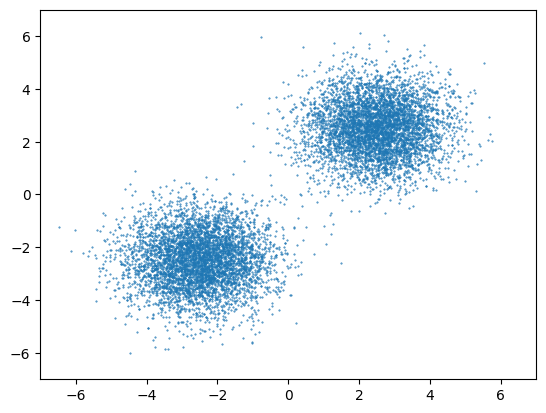

In [51]:
import torch
import torch.nn as nn
import torch_sgld
import seaborn as sns
import matplotlib.pyplot as plt

N = 10000
d = 2
data = torch.randn((int(N/2),d)) + 2.5
data2 = torch.randn((int(N/2),d)) - 2.5
data = torch.cat((data, data2), dim=0)


plt.scatter(data[:,0], data[:,1], s=0.2)
plt.xlim([-7, 7])
plt.ylim([-7, 7])

**1.** Considere as a amostras da distribuição acima, contidas na variável 'data'. Complete o código abaixo para implementar um modelo baseado em energia (EBM) que amostre aproximadamente da distribuição subjacente a esses dados. Depois de treinar o modelo, amostre do EBM e compare o resultado contra o scatterplot acima. Analise o efeito de mudar a quantidade de iterações de SGLD por época. Além disso, a implementação abaixo usa cadeias 'persistentes' entre épocas --- i.e., o estado final da última época é o inicial da atual. Qual o efeito de inicializar aleatoriamente a cadeia em cada iteração? E de inicializá-las nos pontos observados em 'data'?

In [60]:
h = 10
E_persistente = nn.Sequential(
    nn.Linear(d, h), nn.ReLU(),
    nn.Linear(h, h), nn.ReLU(),
    nn.Linear(h, 1)
).to(device)

# Inicializar amostras negativas
x_persistente = torch.randn((N, d), device=device) * 5.0
x_persistente.requires_grad = True

# Otimizador e sampler SGLD
optimizer = torch.optim.Adam(E_persistente.parameters(), lr=0.01)
sampler = torch_sgld.SGLD([x_persistente], lr=0.01)
chain_length = 10
max_iter = 2000 # reduzi para não demorar tanto
loss_persistente = []

# Treinamento com logging de loss
for i in range(max_iter):
    for _ in range(chain_length):
        sampler.zero_grad()
        potential = E_persistente(x_persistente).squeeze()
        potential.sum().backward()
        sampler.step()

    optimizer.zero_grad()
    loss = E_persistente(data).mean() - E_persistente(x_persistente.detach()).mean()
    loss.backward()
    optimizer.step()

    loss_persistente.append(loss.item())

x_persistente = x_persistente.detach().cpu()

Comparando o scatterplot com o enunciado:


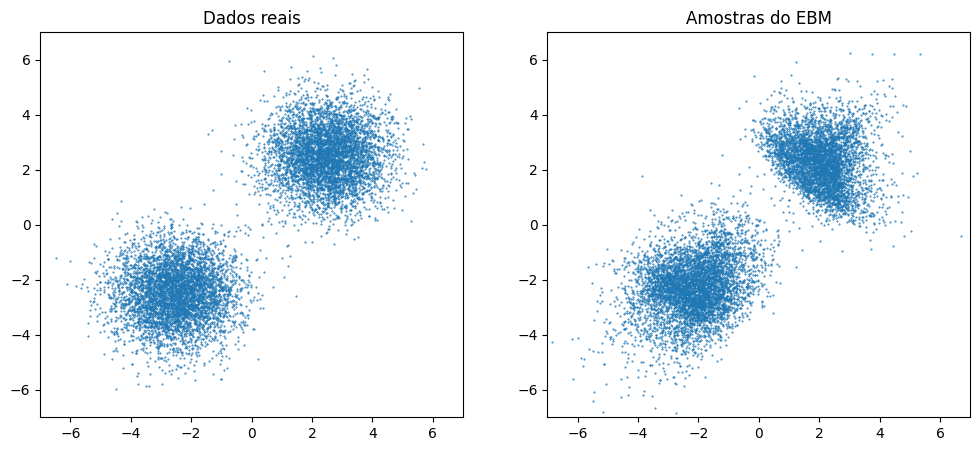

In [61]:
import matplotlib.pyplot as plt

# Plot dos dados reais
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data[:,0].cpu(), data[:,1].cpu(), s=0.2)
plt.title("Dados reais")
plt.xlim([-7, 7])
plt.ylim([-7, 7])

# Plot das amostras do EBM
plt.subplot(1,2,2)
plt.scatter(x_persistente[:,0], x_persistente[:,1], s=0.2)
plt.title("Amostras do EBM")
plt.xlim([-7, 7])
plt.ylim([-7, 7])
plt.show()

O gráfico de dispersão original exibe uma distribuição bimodal nítida, com duas concentrações de pontos bem distintas em duas dimensões. Ao comparar isso com os nossos resultados, fica claro que o modelo conseguiu representar bem essa estrutura: as amostras geradas pelo EBM também formam duas regiões separadas, com formas e densidades que lembram as da distribuição inicial. Isso sugere que o modelo aprendeu uma aproximação eficaz da distribuição que ele deveria modelar.

Vamos agora analisar o efeito de mudar a quantidade de iterações de SGLD por época. Faremos isso testando vários valores para `chain_length` mantendo o número total de iterações (`max_iter = 2000`) fixo:

In [62]:
# Treinamento com logging de loss para varias chain_length enquanto mantemos todos os outros parâmetros
chain_lengths = [2, 5, 10, 20]
all_losses = []
final_samples = []

for chain_length in chain_lengths:
    print(chain_length)

    # Recria modelo, amostras, sampler e otimizador para cada chain_length
    E = nn.Sequential(nn.Linear(d, h), nn.ReLU(),nn.Linear(h, h), nn.ReLU(),nn.Linear(h, 1)).to(device)
    x = torch.randn((N, d), device=device) * 5.0
    x.requires_grad = True
    sampler = torch_sgld.SGLD([x], lr=0.01)
    optimizer = torch.optim.Adam(E.parameters(), lr=0.01)

    losses = []
    for i in range(max_iter):
        for _ in range(chain_length):
            sampler.zero_grad()
            potential = E(x).squeeze()
            potential.sum().backward()
            sampler.step()

        optimizer.zero_grad()
        loss = E(data).mean() - E(x.detach()).mean()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    all_losses.append(losses)
    final_samples.append(x.detach().cpu())

x = x.detach().cpu()

2
5
10
20


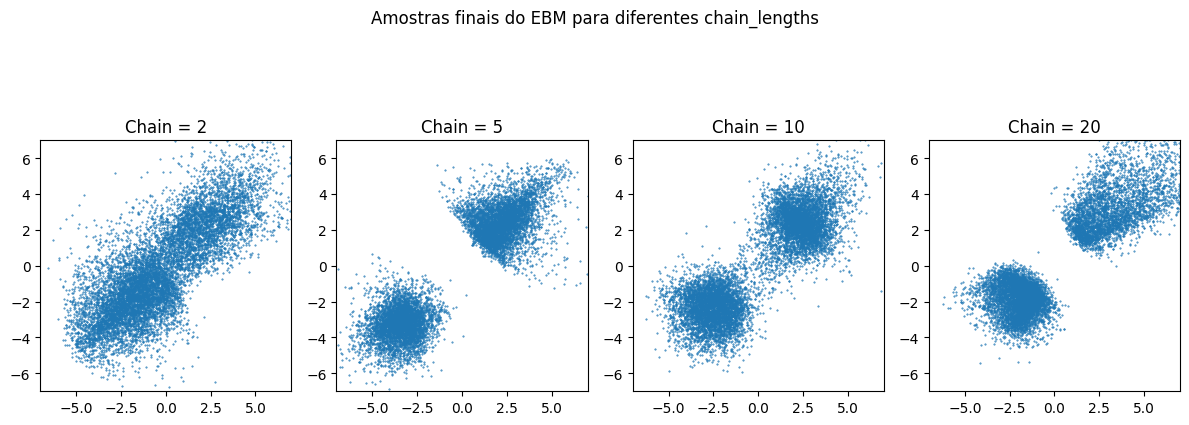

In [63]:
# Plotando os scatterplots lado a lado
fig, axs = plt.subplots(1, len(chain_lengths), figsize=(12, 5))
for i, chain_length in enumerate(chain_lengths):
    axs[i].scatter(final_samples[i][:, 0], final_samples[i][:, 1], s=0.2)
    axs[i].set_title(f"Chain = {chain_length}")
    axs[i].set_xlim([-7, 7])
    axs[i].set_ylim([-7, 7])
    axs[i].set_aspect('equal')

plt.suptitle("Amostras finais do EBM para diferentes chain_lengths")
plt.tight_layout()
plt.show()

**2.** Treine um EBM via máxima verossimlhança usando o MNIST. Mostre as amostras geradas pelo modelo. Crie um conjunto de amostras do EBM e mostre o histograma de suas respectivas energias. Mostre e comente alguns exemplos de amostras de alta e de baixa energia.


In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Vamos treinar o EBM via MNIST e mostrar as amostras geradas pelo modelo:

In [65]:
# Modelo de Energia
class EnergyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 400),
            nn.ReLU(),
            nn.Linear(400, 1)  # Saída escalar = energia
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Achata para vetor
        return self.net(x).squeeze()

# Amostragem com SGLD
def sgld_sample(model, steps=60, step_size=0.1, noise_scale=0.01, batch_size=64):
    x = torch.rand(batch_size, 1, 28, 28).to(device)  # Inicializa com ruído uniforme

    x.requires_grad = True
    for _ in range(steps):
        energy = model(x)
        grad = torch.autograd.grad(energy.sum(), x, create_graph=False)[0]
        noise = torch.randn_like(x) * noise_scale
        x = x - step_size * grad + noise
        x = x.clamp(0, 1).detach()  # Projeta e evita explodir
        x.requires_grad = True

    return x.detach()

# Dados
transform = transforms.Compose([transforms.ToTensor()])
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(mnist_train, batch_size=64, shuffle=True)

# Treinamento
model = EnergyModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):
    for i, (real_x, _) in enumerate(loader):
        real_x = real_x.to(device)

        # Gera amostras negativas
        fake_x = sgld_sample(model, batch_size=real_x.size(0))

        # Energias
        energy_real = model(real_x)
        energy_fake = model(fake_x)

        # Perda de máxima verossimilhança
        loss = (energy_real.mean() - energy_fake.mean())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: -1.2256
Epoch 2, Loss: -0.4017
Epoch 3, Loss: 0.0957
Epoch 4, Loss: -0.3850
Epoch 5, Loss: -0.7442
Epoch 6, Loss: -0.6076
Epoch 7, Loss: -1.9211
Epoch 8, Loss: 0.9017
Epoch 9, Loss: 0.0704
Epoch 10, Loss: 0.2087


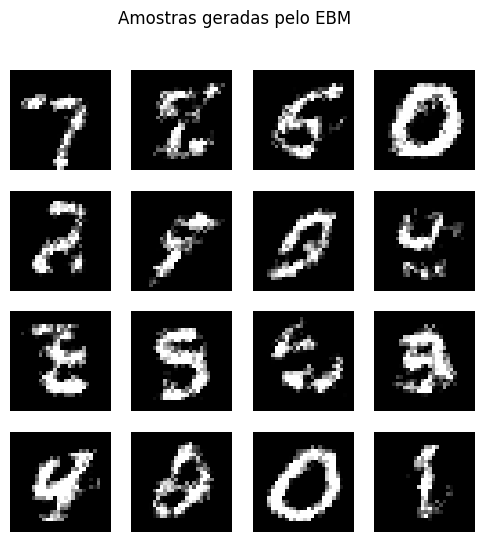

In [66]:
samples = sgld_sample(model, batch_size=64)

# Mostra as primeiras 16 amostras geradas
plt.figure(figsize=(6, 6))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(samples[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Amostras geradas pelo EBM")
plt.show()


Agora, vamos criar um conjunto de amostras do EBM e plotar o histograma de suas respectivas energias.

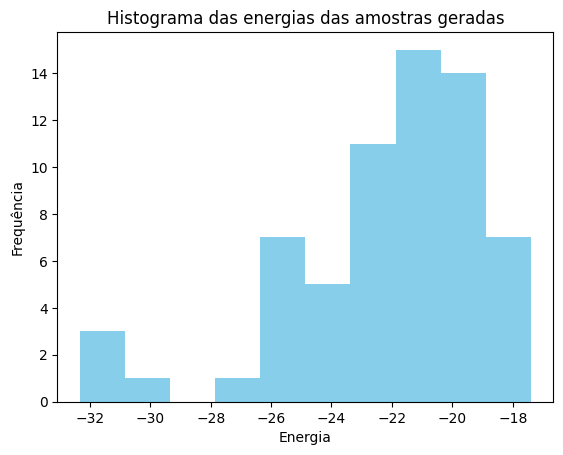

In [67]:
with torch.no_grad():
    energies = model(samples).cpu().numpy()

plt.hist(energies, bins=10, color='skyblue')
plt.xlabel("Energia")
plt.ylabel("Frequência")
plt.title("Histograma das energias das amostras geradas")
plt.show()


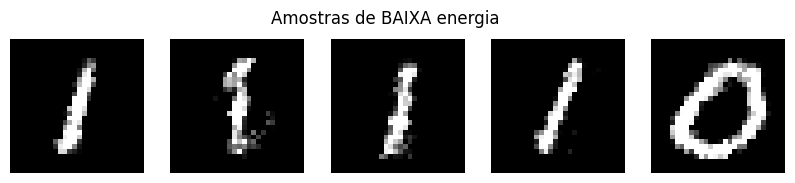

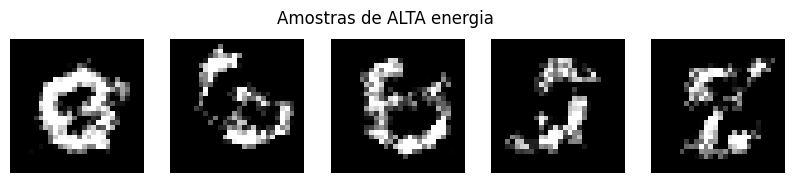

In [68]:
# Ordena por energia
sorted_indices = np.argsort(energies)
low_energy_imgs = samples[sorted_indices[:5]]
high_energy_imgs = samples[sorted_indices[-5:]]

# Baixa energia
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(low_energy_imgs[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Amostras de BAIXA energia")
plt.show()

# Alta energia
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(high_energy_imgs[i].cpu().squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Amostras de ALTA energia")
plt.show()


Quando visualizamos as imagens, percebemos que as amostras de baixa energia tendem a ser do dígito 1, que é mais simples e fácil de identificar. Por outro lado, as amostras de alta energia parecem ser de dígitos mais complexos, resultando em imagens confusas. Essa descoberta faz sentido, já que o modelo atribui maior energia (ou menor probabilidade) a qualquer entrada que se desvie do padrão que ele aprendeu.

In [50]:
!pip install torch_sgld

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 65.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 61.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink